In [1]:
# ============================================
# Climate Risk Analysis — Phase 2
# Step 1: Load data and explore
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Load all tables
climate = pd.read_csv("fact_climate.csv")
economic = pd.read_csv("fact_economic.csv")
countries = pd.read_csv("dim_country.csv")
years = pd.read_csv("dim_year.csv")

print("=== Dataset Overview ===")
print(f"Climate data:  {len(climate)} years ({climate.year.min()}–{climate.year.max()})")
print(f"Economic data: {len(economic)} rows")
print(f"Countries:     {len(countries)}")
print()
print("=== Climate Data Sample ===")
print(climate.tail(10))

=== Dataset Overview ===
Climate data:  56 years (1970–2025)
Economic data: 817 rows
Countries:     15

=== Climate Data Sample ===
    year  temp_anomaly_c  temp_anomaly_rolling10y anomaly_tier
46  2016            1.01                    0.717         High
47  2017            0.92                    0.743     Moderate
48  2018            0.85                    0.774     Moderate
49  2019            0.98                    0.806     Moderate
50  2020            1.01                    0.835         High
51  2021            0.85                    0.859     Moderate
52  2022            0.89                    0.884     Moderate
53  2023            1.17                    0.933         High
54  2024            1.29                    0.987         High
55  2025            1.19                    1.016         High


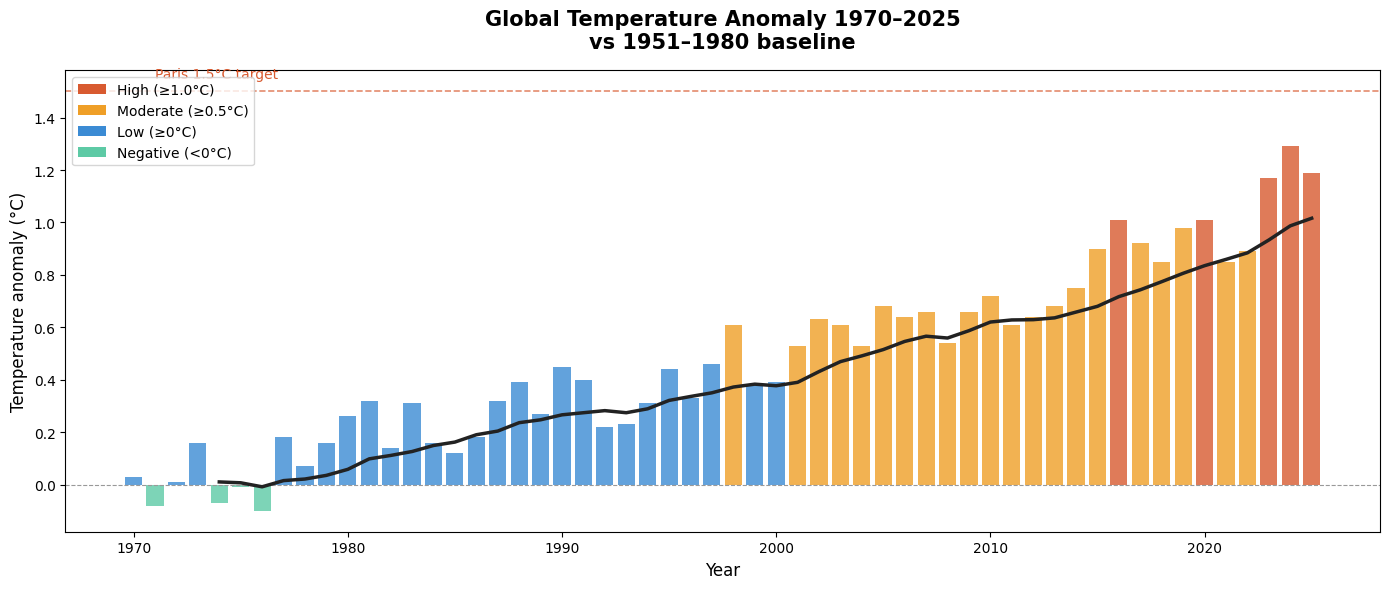

Chart saved!


In [2]:
# ============================================
# Chart 1: Global Temperature Anomaly Trend
# ============================================

fig, ax = plt.subplots(figsize=(14, 6))

# Color bars by tier
colors = climate["anomaly_tier"].map({
    "High": "#D85A30",
    "Moderate": "#EF9F27",
    "Low": "#3B8BD4",
    "Negative": "#5DCAA5"
})

# Bar chart — one bar per year
ax.bar(climate["year"], climate["temp_anomaly_c"], color=colors, alpha=0.8, width=0.8)

# Rolling average line on top
ax.plot(climate["year"], climate["temp_anomaly_rolling10y"],
        color="#222", linewidth=2.5, label="10-year average", zorder=5)

# Reference line at 0
ax.axhline(0, color="#999", linewidth=0.8, linestyle="--")

# Paris Agreement line
ax.axhline(1.5, color="#D85A30", linewidth=1.2, linestyle="--", alpha=0.7)
ax.text(1971, 1.55, "Paris 1.5°C target", fontsize=10, color="#D85A30")

# Labels
ax.set_title("Global Temperature Anomaly 1970–2025\nvs 1951–1980 baseline",
             fontsize=15, fontweight="bold", pad=16)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Temperature anomaly (°C)", fontsize=12)
ax.legend(fontsize=11)

# Manual legend for tiers
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#D85A30", label="High (≥1.0°C)"),
    Patch(facecolor="#EF9F27", label="Moderate (≥0.5°C)"),
    Patch(facecolor="#3B8BD4", label="Low (≥0°C)"),
    Patch(facecolor="#5DCAA5", label="Negative (<0°C)"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=10)

plt.tight_layout()
plt.savefig("temperature_trend.png", dpi=150)
plt.show()
print("Chart saved!")

Countries available: 15
   country_code                                   country_name  \
0           AFE                    Africa Eastern and Southern   
1           AFW                     Africa Western and Central   
2           ARB                                     Arab World   
3           CEB                 Central Europe and the Baltics   
4           CSS                         Caribbean small states   
5           EAP    East Asia & Pacific (excluding high income)   
6           EAR                     Early-demographic dividend   
7           ECA  Europe & Central Asia (excluding high income)   
8           EMU                                      Euro area   
9           EUU                                 European Union   
10          FCS       Fragile and conflict affected situations   
11          HPC         Heavily indebted poor countries (HIPC)   
12          IBD                                      IBRD only   
13          TEA     East Asia & Pacific (IDA & IBRD 

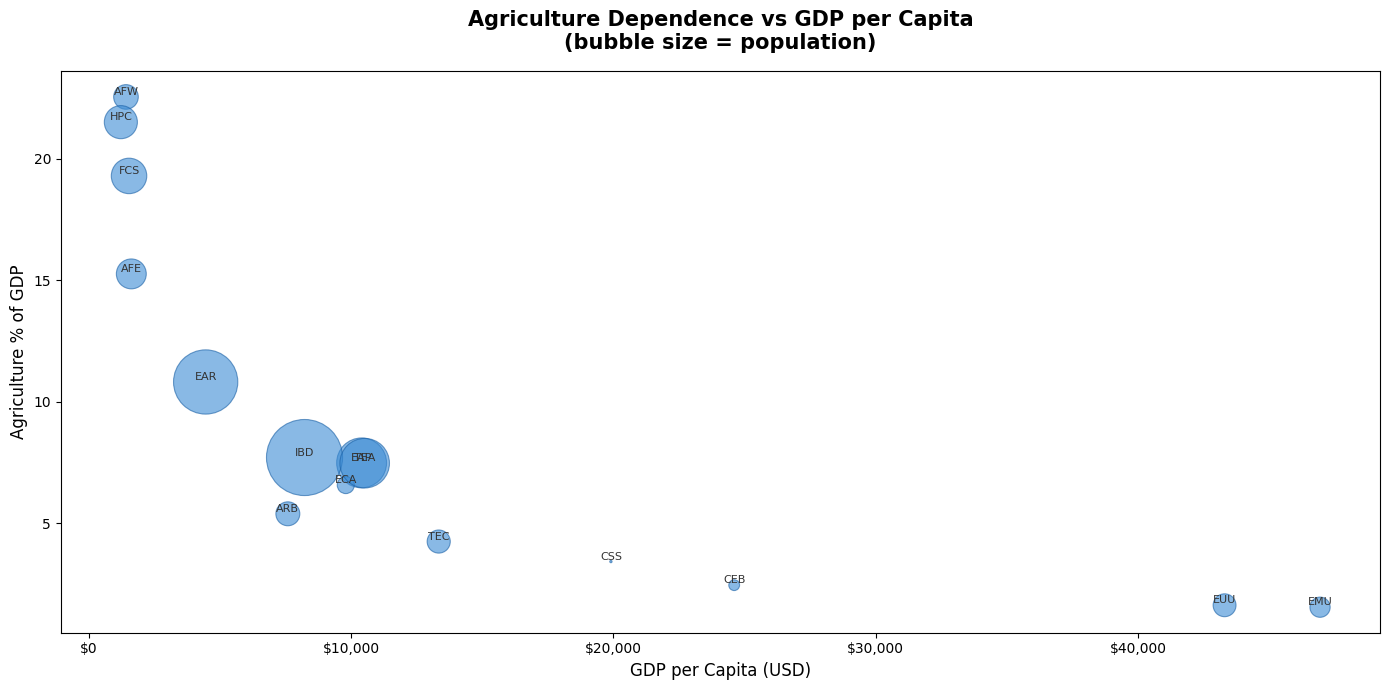

Chart saved!


In [4]:
# ============================================
# Chart 2: GDP per Capita by Country Group
# ============================================

# Get latest year available for each country
latest = economic.sort_values("year").groupby("country_code").last().reset_index()

# Drop rows missing the columns we need
latest = latest.dropna(subset=["gdp_per_capita_usd", "population"])

# Merge with country names
latest = latest.merge(countries, on="country_code", how="left")

# Fill missing country names with code
latest["country_name"] = latest["country_name"].fillna(latest["country_code"])

print(f"Countries available: {len(latest)}")
print(latest[["country_code", "country_name", "gdp_per_capita_usd", "population"]])

fig, ax = plt.subplots(figsize=(14, 7))

# Bubble size = population
bubble_size = (latest["population"] / latest["population"].max()) * 3000

ax.scatter(
    latest["gdp_per_capita_usd"],
    latest["agriculture_pct_gdp"],
    s=bubble_size,
    alpha=0.6,
    color="#3B8BD4",
    edgecolors="#185FA5",
    linewidth=0.8
)

# Label each bubble
for _, row in latest.iterrows():
    ax.annotate(
        row["country_code"],
        (row["gdp_per_capita_usd"], row["agriculture_pct_gdp"]),
        fontsize=8,
        ha="center",
        va="bottom",
        color="#333"
    )

ax.set_title("Agriculture Dependence vs GDP per Capita\n(bubble size = population)",
             fontsize=15, fontweight="bold", pad=16)
ax.set_xlabel("GDP per Capita (USD)", fontsize=12)
ax.set_ylabel("Agriculture % of GDP", fontsize=12)

import matplotlib.ticker as mticker
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x:,.0f}"
))

plt.tight_layout()
plt.savefig("agri_vs_gdp.png", dpi=150)
plt.show()
print("Chart saved!")

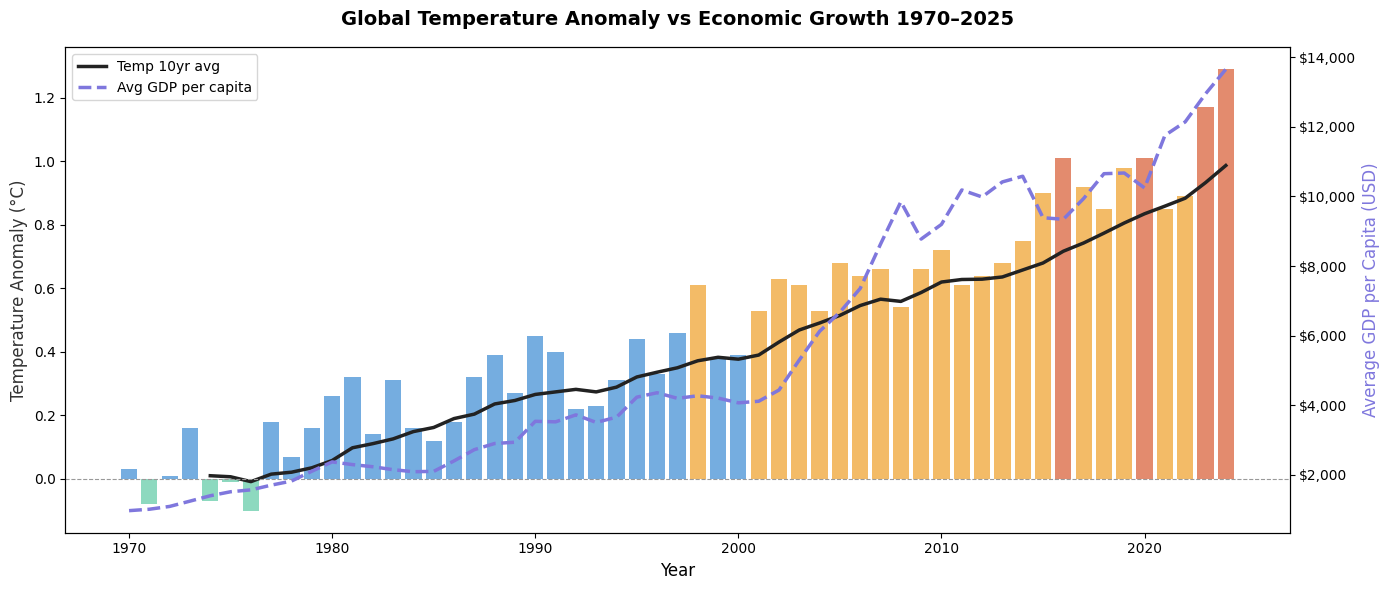

Chart saved!


In [5]:
# ============================================
# Chart 3: Temperature Rise vs Time
# with economic vulnerability overlay
# ============================================

# Get average GDP per capita across all groups per year
gdp_trend = economic.groupby("year")["gdp_per_capita_usd"].mean().reset_index()
gdp_trend.columns = ["year", "avg_gdp_per_capita"]

# Merge with climate
merged = climate.merge(gdp_trend, on="year", how="inner")

fig, ax1 = plt.subplots(figsize=(14, 6))

# Left axis — temperature
colors = merged["anomaly_tier"].map({
    "High": "#D85A30",
    "Moderate": "#EF9F27",
    "Low": "#3B8BD4",
    "Negative": "#5DCAA5"
})
ax1.bar(merged["year"], merged["temp_anomaly_c"],
        color=colors, alpha=0.7, width=0.8)
ax1.plot(merged["year"], merged["temp_anomaly_rolling10y"],
         color="#222", linewidth=2.5, label="Temp 10yr avg")
ax1.set_ylabel("Temperature Anomaly (°C)", fontsize=12, color="#333")
ax1.axhline(0, color="#999", linewidth=0.8, linestyle="--")

# Right axis — GDP
ax2 = ax1.twinx()
ax2.plot(merged["year"], merged["avg_gdp_per_capita"],
         color="#7F77DD", linewidth=2.5,
         linestyle="--", label="Avg GDP per capita")
ax2.set_ylabel("Average GDP per Capita (USD)", fontsize=12, color="#7F77DD")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x:,.0f}"
))

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=10)

ax1.set_title("Global Temperature Anomaly vs Economic Growth 1970–2025",
              fontsize=14, fontweight="bold", pad=16)
ax1.set_xlabel("Year", fontsize=12)

plt.tight_layout()
plt.savefig("temp_vs_gdp_trend.png", dpi=150)
plt.show()
print("Chart saved!")

In [6]:
# ============================================
# Phase 2 Summary
# ============================================

print("=== Phase 2 Complete ===")
print()
print("Charts produced:")
print("  ✓ temperature_trend.png   — 55 years of global warming")
print("  ✓ agri_vs_gdp.png         — economic vulnerability by region")
print("  ✓ temp_vs_gdp_trend.png   — climate vs economic growth")
print()
print("Key findings:")
print()

# Finding 1
hottest = climate.loc[climate["temp_anomaly_c"].idxmax()]
print(f"  🌡  Hottest year on record: {int(hottest.year)} ({hottest.temp_anomaly_c}°C above baseline)")

# Finding 2
high_years = climate[climate["anomaly_tier"] == "High"]
print(f"  📈  Years above 1.0°C threshold: {len(high_years)} ({int(high_years.year.min())}–{int(high_years.year.max())})")

# Finding 3
latest_anomaly = climate[climate["year"] == climate.year.max()].iloc[0]
print(f"  📅  Latest reading ({int(latest_anomaly.year)}): {latest_anomaly.temp_anomaly_c}°C — tier: {latest_anomaly.anomaly_tier}")

# Finding 4
richest = economic.sort_values("year").groupby("country_code").last()
richest = richest.sort_values("gdp_per_capita_usd", ascending=False).reset_index()
richest = richest.merge(countries, on="country_code", how="left")
print(f"  💰  Highest GDP group: {richest.iloc[0].country_name} (${richest.iloc[0].gdp_per_capita_usd:,.0f}/capita)")
print(f"  🌾  Most agriculture dependent: {richest.iloc[-1].country_name}")

print()
print("Next → Power BI dashboard")

=== Phase 2 Complete ===

Charts produced:
  ✓ temperature_trend.png   — 55 years of global warming
  ✓ agri_vs_gdp.png         — economic vulnerability by region
  ✓ temp_vs_gdp_trend.png   — climate vs economic growth

Key findings:

  🌡  Hottest year on record: 2024 (1.29°C above baseline)
  📈  Years above 1.0°C threshold: 5 (2016–2025)
  📅  Latest reading (2025): 1.19°C — tier: High
  💰  Highest GDP group: Euro area ($46,945/capita)
  🌾  Most agriculture dependent: Heavily indebted poor countries (HIPC)

Next → Power BI dashboard
